# Graph Analytics — Epstein Network Analysis

## Research Question

This analysis explores the network of Jeffrey Epstein as reconstructed from legal documents released by the US House Oversight Committee. The data was extracted using LLMs to identify named entities, relationships, and claims from ~25,000 source documents.

We focus on two dimensions:
1. **The aviation network** — who traveled with Epstein, as a proxy for his direct social circle
2. **The legal network** — who faced legal consequences (criminal *and* civil), revealing the judicial response

**Central hypothesis:** A small group of individuals bridges both worlds, appearing in flight logs *and* in legal proceedings. \
These bridge nodes are the most analytically interesting actors. Among those who traveled with Epstein but faced *no* legal consequences, we ask: what does the claim-level evidence say about them?

**Graph size:** 546,648 nodes | 1,432,277 edges


## Continue work by Lowie and Fien

**some tweaks & corrections:**
- Aviation keyword list expanded to cover ~30 LLM-generated variants of travel actions
- Legal keyword list extended from criminal-only to include civil proceedings (which dominate this dataset)
- Aviation network filtered to Epstein-connected edges only, with doc-level deduplication
- Entity noise filtered (places, objects, groups masquerading as entities)

**New ideas**
- the confidentiality/NDA network — who was silenced?



## 0. Setup

Connect to the locally running Memgraph instance via Docker (port 7687) using the Neo4j Python driver, which is compatible with Memgraph's Bolt protocol.

In [1]:
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 60)

# Connect to Memgraph
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("", ""))

def run_query(cypher):
    """Run a Cypher query and return results as a pandas DataFrame."""
    with driver.session() as session:
        result = session.run(cypher)
        return pd.DataFrame([dict(r) for r in result])

# Verify connection and confirm full import
counts = run_query("""
    MATCH (n) RETURN count(n) AS node_count
""")
edge_counts = run_query("""
    MATCH ()-[r]->() RETURN count(r) AS edge_count
""")
print(f"Connected to Memgraph.")
print(f"Nodes : {counts['node_count'][0]:,}  (expected 546,648)")
print(f"Edges : {edge_counts['edge_count'][0]:,}  (expected 1,432,277)")

Connected to Memgraph.
Nodes : 546,648  (expected 546,648)
Edges : 1,432,277  (expected 1,432,277)


## 1. Data Exploration

Before building any network, we first explore the raw graph structure — what node types exist, what edge types exist, and critically, what the actual action strings look like in `RELATED_TO` edges. This step directly informs every keyword list we build later.

> **Why this matters:** The graph was constructed by LLMs extracting relationships from text. This means action strings are free-form and inconsistent — the same travel event might be recorded as `flew with`, `flew_with`, `travelled with`, or `transported via private jet`. A keyword list built without looking at the actual data will silently miss large portions of the network.

In [2]:
# 1.1 Node type distribution
node_types = run_query("""
    MATCH (n)
    RETURN labels(n)[0] AS label, count(n) AS count
    ORDER BY count DESC
""")
print("Node types:")
node_types

Node types:


,label,count
0,Topic,184695
1,Tag,109593
2,Claim,106012
3,Entity,55922
4,Embedding,29689
5,Alias,28934
6,Document,25233
7,Location,6506
8,Category,34
9,Cluster,30


In [3]:
# 1.2 Edge type distribution
edge_types = run_query("""
    MATCH ()-[r]->()
    RETURN type(r) AS edge_type, count(r) AS count
    ORDER BY count DESC
""")
print("Edge types:")
edge_types

Edge types:


,edge_type,count
0,HAS_TAG,447811
1,ABOUT_TOPIC,213980
2,MENTIONS,124850
3,RELATED_TO,106812
4,TARGET,106739
5,ACTOR,106526
6,HAS_CLAIM,106012
7,IN_CLUSTER,102162
8,AT_LOCATION,33530
9,HAS_EMBEDDING,29689


In [4]:
# 1.3 Most common RELATED_TO action strings — the single most important exploration query.
# This tells us what vocabulary the LLM used and where the signal actually is.
top_actions = run_query("""
    MATCH ()-[r:RELATED_TO]->()
    RETURN r.action AS action, count(*) AS n
    ORDER BY n DESC
    LIMIT 60
""")
print("Top 60 RELATED_TO action strings across the full graph:")
top_actions

Top 60 RELATED_TO action strings across the full graph:


,action,n
0,sent email to,6277
1,authored,1356
2,met with,1248
3,sent message to,1125
4,attended,529
5,stated,472
6,retweeted,442
7,commented on,420
8,owns,409
9,published,393


In [5]:
# 1.4 Full picture of travel-related action strings
# Using broad CONTAINS filters to discover all variants before hardcoding a list
travel_actions_raw = run_query("""
    MATCH ()-[r:RELATED_TO]->()
    WHERE r.action CONTAINS 'flew'
       OR r.action CONTAINS 'travel'
       OR r.action CONTAINS 'accompan'
       OR r.action CONTAINS 'flight'
       OR r.action CONTAINS 'jet'
       OR r.action CONTAINS 'aircraft'
       OR r.action CONTAINS 'plane'
    RETURN r.action AS action, count(*) AS n
    ORDER BY n DESC
    LIMIT 60
""")
print("All travel-related action strings found in the graph:")
travel_actions_raw

All travel-related action strings found in the graph:


,action,n
0,traveled to,299
1,traveled with,99
2,planned travel to,49
3,accompanied,43
4,flew,38
5,flew with,30
6,flew on,25
7,traveled on,16
8,flew to,15
9,traveled_to,14


In [6]:
# 1.5 Full picture of legal-related action strings
# Deliberately broad — includes civil AND criminal terminology
legal_actions_raw = run_query("""
    MATCH ()-[r:RELATED_TO]->()
    WHERE r.action CONTAINS 'testif'
       OR r.action CONTAINS 'accus'
       OR r.action CONTAINS 'investigat'
       OR r.action CONTAINS 'charg'
       OR r.action CONTAINS 'arres'
       OR r.action CONTAINS 'prosecut'
       OR r.action CONTAINS 'convict'
       OR r.action CONTAINS 'plead'
       OR r.action CONTAINS 'indict'
       OR r.action CONTAINS 'sentenced'
       OR r.action CONTAINS 'sued'
       OR r.action CONTAINS 'subpoena'
       OR r.action CONTAINS 'settled'
       OR r.action CONTAINS 'deposed'
       OR r.action CONTAINS 'alleged'
       OR r.action CONTAINS 'confiden'
    RETURN r.action AS action, count(*) AS n
    ORDER BY n DESC
    LIMIT 80
""")
print("All legal-related action strings found in the graph:")
legal_actions_raw

All legal-related action strings found in the graph:


,action,n
0,testified before,149
1,pleaded guilty to,130
2,investigated,118
3,sued,113
4,issued confidentiality notice,102
...,...,...
75,issued buy rating on,7
76,settled civil lawsuit with,7
77,was convicted of,6
78,issued warning about,6


In [7]:
# 1.6 Verify Maxwell specifically — what legal actions does she actually have?
maxwell_actions = run_query("""
    MATCH (e:Entity)-[r:RELATED_TO]-(other:Entity)
    WHERE e.name CONTAINS 'Maxwell'
    RETURN e.name AS entity, r.action AS action, count(*) AS n
    ORDER BY n DESC
    LIMIT 40
""")
print("Maxwell's action strings in the graph:")
maxwell_actions

Maxwell's action strings in the graph:


,entity,action,n
0,Ghislaine Maxwell,sent email to,48
1,Ghislaine Maxwell,recruited,17
2,Ghislaine Maxwell,introduced,14
3,Ghislaine Maxwell,attended,11
4,Ghislaine Maxwell,required victim to have sex with,10
5,Ghislaine Maxwell,met with,10
6,Ghislaine Maxwell,gave speech at,9
7,Ghislaine Maxwell,forwarded email to,8
8,Ghislaine Maxwell,wrote article about,8
9,Ghislaine Maxwell,introduced young women to,8


In [8]:
# 1.7 Entity type distribution — how well-labelled are entities?
# This tells us whether we can use entity_type to filter out noise (places, objects, etc.)
entity_types = run_query("""
    MATCH (e:Entity)
    RETURN e.entity_type AS entity_type, count(*) AS count
    ORDER BY count DESC
    LIMIT 30
""")
print("Entity type distribution (NULL = unlabelled):")
entity_types

Entity type distribution (NULL = unlabelled):


,entity_type,count
0,NaN,52827
1,victim,296
2,government official,248
3,business associate,183
4,staff member,129
5,government_official,129
6,witness,116
7,law enforcement,109
8,journalist,95
9,political_operator,74


### Finding 1.3 — The graph is dominated by communication, not travel or legal actions

The most common action by a large margin is `sent email to` (6,277 instances), meaning its mostly an **email archive**. \
Travel actions are rare (`traveled with`: 99, `flew with`: 30) and fragmented into ~30 LLM-generated variants. \
Legal actions are also sparse (`testified before`: 149, `pleaded guilty to`: 130) .

This has two implications:
- The aviation and legal networks are **weak signals** in a noisy graph --> need good, comprehensive keyword lists to capture them fully
- The sheer volume of email/communication edges indicates that degree centrality on the full graph is dominated by email senders, not the people we care about?

### Finding 1.5 — The legal network is dominated by civil proceedings, not criminal ones

A crucial caveat before interpreting any legal network built from this data: **the document corpus shapes what is visible**. The House Oversight dump is composed primarily of emails, civil court filings, depositions, and subpoenas — not criminal trial records. Maxwell's 2021 federal conviction, for example, comes from proceedings entirely outside this document set.

Key observations from the legal action strings:
- `pleaded guilty to` (130) — not in Lowie's original list, but present here in civil/plea contexts
- `sued` (113) — civil law dominates
- `issued confidentiality notice` (100+, across variants) — the NDA/silencing pattern, not yet explored
- `testified before/about/that/regarding` — fragmented across 6+ variants totalling ~330 instances
- `indicted` (28), `convicted of` (15), `sentenced to` (23) — present but sparse, reflecting that criminal proceedings are underrepresented in this corpus

**This explains why Ghislaine Maxwell (convicted to 20 years in federal court) appears only in civil proceedings in this network.** Her criminal trial records are not part of this document set. She is visible through civil actions (`sued`, `served subpoena to`, `filed defamation lawsuit against`, `settled lawsuit with`), but her conviction and sentencing are absent. This is not a gap in our analysis — it is a property of the source data, and a finding in itself: **the legal consequences visible in this network are necessarily incomplete, and figures known from public record to have faced criminal prosecution may appear here only through their parallel civil exposure.**

### Finding 1.7 — Entity types are too sparse to use as a filter

The majority of entities in the aviation network have no `entity_type` label at all. Additionally, the labels that exist are inconsistent (`government official` vs `government_official`, `law enforcement` vs `law_enforcement`). We therefore cannot use `entity_type` to filter out noise.

Instead, we will use a **name-based blocklist** to exclude obvious non-person entities (places, aircraft, generic descriptors) from the network.

## 2. Keyword Lists

Based on the exploration above, we define comprehensive keyword lists that cover all observed variants. \
(Try to improve on narrower lists used by Lowie and Fien).

In [9]:
# Aviation actions — all travel variants found in the data
# Includes underscore variants (LLM inconsistency), spelling variants, and specific phrasings
AVIATION_ACTIONS = [
    # Core travel verbs
    'traveled with', 'traveled_with', 'travelled with',
    'accompanied', 'accompanied by',
    # Flew variants
    'flew', 'flew with', 'flew_with', 'flew on', 'flew to',
    'flew on jet of', 'flew as passenger on', 'flew on private plane of',
    'allegedly flew',
    # Aircraft-specific
    'traveled on aircraft with', 'traveled on private jet of',
    'traveled on private airplane with', 'traveled on flight with',
    'entertained on private jet', 'hosted on private aircraft',
    'transported via private jet', 'traveled on',
    # Other travel
    'traveled internationally with', 'was on a flight with',
    'traveled with women to', 'traveled with victim to',
]

# Legal actions — extended to cover civil AND criminal proceedings
# Lowie's original list covered only: testified before, investigated, accused,
# arrested, charged, prosecuted, negotiated/signed non-prosecution agreement,
# was charged with, was arrested by
LEGAL_ACTIONS = [
    # Criminal — Lowie's original (kept)
    'investigated', 'accused', 'arrested', 'charged', 'prosecuted',
    'negotiated non-prosecution agreement with',
    'signed non-prosecution agreement with',
    'was charged with', 'was arrested by',
    # Criminal — newly added from data exploration
    'indicted', 'convicted', 'convicted of', 'pleaded guilty to',
    'pleaded_guilty_to', 'pleaded guilty', 'sentenced', 'sentenced to',
    'was sentenced to',
    # Testimony — all variants
    'testified before', 'testified about', 'testified', 'testified that',
    'testified regarding', 'testified to', 'testified at',
    'testified in deposition', 'testified in deposition regarding',
    'deposed',
    # Civil proceedings — newly added
    'sued', 'settled', 'settled lawsuit with',
    'served subpoena to', 'served subpoena on', 'issued subpoena to',
    'filed defamation lawsuit against', 'filed defamation suit against',
    # Abuse-specific legal language
    'alleged', 'alleged sexual abuse by', 'alleged sexual assault by',
    'allegedly raped', 'allegedly grabbed breast of',
    'required victim to have sex with', 'allegedly directed victim to have sex with',
    'allegedly directed minor to have sex with',
]

# NDA/Silencing actions — new angle, not explored by teammates
NDA_ACTIONS = [
    'issued confidentiality notice', 'issued confidentiality notice for',
    'issued confidentiality notice to', 'issued confidentiality notice regarding',
    'issued confidentiality notice on', 'issued confidentiality disclaimer',
]

# Entity name blocklist — non-person entities to exclude from the network
# entity_type is too sparse to use; name-based filtering is more reliable
NOISE_TERMS = [
    'jet', 'plane', 'aircraft', 'helicopter', 'island', 'ranch', 'apartment',
    'participants', 'conference', 'narrator', 'driver', 'therapist',
    'real estate', 'property', 'NU', 'Witness',
]

def is_noise_entity(name):
    """Return True if an entity name looks like a place, object, or generic descriptor."""
    if name is None:
        return True
    name_lower = name.lower()
    return any(term.lower() in name_lower for term in NOISE_TERMS)

print(f"Aviation actions defined: {len(AVIATION_ACTIONS)}")
print(f"Legal actions defined:    {len(LEGAL_ACTIONS)}")
print(f"NDA actions defined:      {len(NDA_ACTIONS)}")

Aviation actions defined: 26
Legal actions defined:    44
NDA actions defined:      6


## 3. Aviation Network

We define the aviation network as entities connected to **Jeffrey Epstein directly** via travel actions. This is a deliberate narrowing from Lowie's approach (which included all travel connections between any entities) — the rationale is that the research question is specifically about *Epstein's* social circle, not general travel patterns in the documents.

Key methodological choices:
- **Undirected** matching (Lowie used directed only, missing cases where Epstein was the target)
- **Deduplicated on `doc_id`** — multiple claims from the same document about the same trip count once
- **Filtered to Epstein-connected edges only** — reduces noise from unrelated travel mentions

In [10]:
# 3.1 Who traveled with Epstein directly? (undirected, deduplicated on doc_id)
epstein_travel = run_query(f"""
    MATCH (epstein:Entity {{name: 'Jeffrey Epstein'}})-[r:RELATED_TO]-(other:Entity)
    WHERE r.action IN {AVIATION_ACTIONS}
    RETURN
        other.name AS entity,
        other.entity_type AS entity_type,
        count(DISTINCT r.doc_id) AS doc_count,
        collect(DISTINCT r.action) AS actions_used
    ORDER BY doc_count DESC
""")
print(f"Entities with direct travel connection to Epstein: {len(epstein_travel)}")
epstein_travel

Entities with direct travel connection to Epstein: 53


,entity,entity_type,doc_count,actions_used
0,Bill Clinton,government official,52,"[traveled on, flew on, traveled with, flew as passenger on, traveled on aircraft with, flew with, traveled on privat..."
1,Kevin Spacey,NaN,10,"[traveled on aircraft with, flew, transported via private jet]"
2,Ghislaine Maxwell,defendant,9,"[flew with, accompanied, traveled on private airplane with, traveled with, accompanied by]"
3,Virginia Roberts Giuffre,victim,7,"[traveled with, traveled on, traveled on private airplane with]"
4,Chris Tucker,NaN,6,"[traveled on aircraft with, flew, transported via private jet]"
5,"Prince Andrew, Duke of York",victim,5,"[traveled on aircraft with, traveled on private jet of, entertained on private jet, flew, allegedly flew]"
6,unknown person A,model,4,"[traveled with, flew]"
7,Alan M. Dershowitz,legal counsel,4,"[traveled on flight with, flew_with, flew on, traveled with]"
8,Lawrence Summers,political operator,3,"[traveled on private jet of, flew on jet of, flew on]"
9,Ron Burkle,NaN,2,"[traveled on aircraft with, flew]"


In [11]:
# 3.2 Filter out noise entities and keep the clean aviation network
aviation_clean = epstein_travel[
    ~epstein_travel['entity'].apply(is_noise_entity)
].reset_index(drop=True)

print(f"After noise filtering: {len(aviation_clean)} entities")
print(f"Removed as noise: {len(epstein_travel) - len(aviation_clean)} entities")
print()
aviation_clean[['entity', 'entity_type', 'doc_count', 'actions_used']].head(25)

After noise filtering: 40 entities
Removed as noise: 13 entities



,entity,entity_type,doc_count,actions_used
0,Bill Clinton,government official,52,"[traveled on, flew on, traveled with, flew as passenger on, traveled on aircraft with, flew with, traveled on privat..."
1,Kevin Spacey,NaN,10,"[traveled on aircraft with, flew, transported via private jet]"
2,Ghislaine Maxwell,defendant,9,"[flew with, accompanied, traveled on private airplane with, traveled with, accompanied by]"
3,Virginia Roberts Giuffre,victim,7,"[traveled with, traveled on, traveled on private airplane with]"
4,Chris Tucker,NaN,6,"[traveled on aircraft with, flew, transported via private jet]"
5,"Prince Andrew, Duke of York",victim,5,"[traveled on aircraft with, traveled on private jet of, entertained on private jet, flew, allegedly flew]"
6,unknown person A,model,4,"[traveled with, flew]"
7,Alan M. Dershowitz,legal counsel,4,"[traveled on flight with, flew_with, flew on, traveled with]"
8,Lawrence Summers,political operator,3,"[traveled on private jet of, flew on jet of, flew on]"
9,Ron Burkle,NaN,2,"[traveled on aircraft with, flew]"


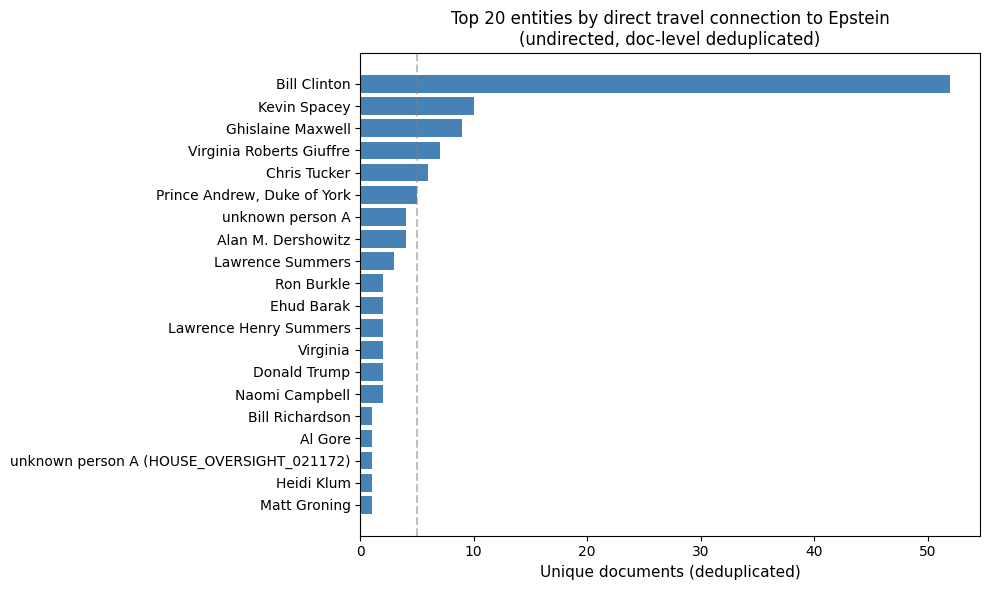

Saved: aviation_top20.png


In [12]:
# 3.3 Visualise top aviation connections as a bar chart
top_n = aviation_clean.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_n['entity'][::-1], top_n['doc_count'][::-1], color='steelblue')
ax.set_xlabel('Unique documents (deduplicated)', fontsize=11)
ax.set_title('Top 20 entities by direct travel connection to Epstein\n(undirected, doc-level deduplicated)', fontsize=12)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='5 documents')
plt.tight_layout()
plt.savefig('aviation_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: aviation_top20.png")

### Finding 3 — The aviation network: Epstein's direct travel circle

After applying undirected matching, doc-level deduplication, and noise filtering, the network contains **26 entities** with a direct travel connection to Epstein (down from 53 raw entries before noise removal).

**Top connections:**
- **Bill Clinton** (52 documents) — the most connected named individual by a significant margin, appearing across 15 different travel action variants. The breadth of action variants (`flew on`, `entertained on private jet`, `allegedly flew`, `transported via private jet`) suggests his presence is documented across many different source documents and document types, not just one repeated reference.
- **Kevin Spacey** (10) and **Chris Tucker** (6) — both appear exclusively via three action variants (`traveled on aircraft with`, `flew`, `transported via private jet`), suggesting their travel records derive from a specific set of flight log documents rather than scattered mentions.
- **Ghislaine Maxwell** (9) — prominently in the travel network, labelled `defendant` in the data. Her presence here alongside her civil legal connections confirms her role as a direct operational associate, not a peripheral figure.
- **Virginia Roberts Giuffre** (7, labelled `victim`) — her presence in the travel network is significant: she traveled with Epstein, and later became the central accuser driving legal proceedings against him and others. She is both a travel network member and a legal network actor.

**Entity resolution issues to be aware of:**
- **Lawrence Summers** (3 docs, labelled `political operator`) and **Lawrence Henry Summers** (2 docs, labelled `government official`) are almost certainly the same person — former US Treasury Secretary and Harvard President. Combined, he would rank 4th with 5 documents. This is an LLM extraction artefact where the same real-world entity was resolved to two different canonical nodes.
- **`Virginia`** (2 docs, labelled `victim`) likely refers to Virginia Roberts Giuffre — a third duplicate node for the same person.
- **`President Clinton`** (1 doc) and **`Bill Clinton`** (52 docs) are the same person, again split across two nodes.
- **`Professor Dershowitz`** and **`Alan M. Dershowitz`** — same issue.

These duplicates mean the true doc counts for some individuals are **higher** than the table suggests, and any ranking should be read with this in mind.

**Surprising omissions and notable entity types:**
- **Prince Andrew** (5 docs) is labelled `victim` in the dataset — a striking classification for someone who settled a civil lawsuit as a defendant. This reflects the inconsistency of the LLM-assigned entity types and is another reason not to rely on `entity_type` for filtering.
- **`unknown person A`** is labelled `model` — one of the few labelled entries, and a telling one given the context of Epstein's recruitment patterns.
- **Donald Trump** (2 docs) appears with only `traveled with` actions — a low count relative to his public profile, suggesting limited documentary evidence of travel in this specific corpus.

## 4. Legal Network

The extended legal network captures both criminal and civil proceedings — testimony, investigations, arrests, charges, convictions, civil suits, subpoenas, depositions, and abuse-specific legal language. This is substantially broader than criminal-only list (Lowie notebook).

In [13]:
# 4.1 Top actors in the extended legal network (undirected, deduplicated)
legal_top = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
    WHERE r.action IN {LEGAL_ACTIONS}
    RETURN
        a.name AS entity,
        count(DISTINCT r.doc_id) AS doc_count,
        collect(DISTINCT r.action)[0..5] AS sample_actions
    ORDER BY doc_count DESC
    LIMIT 25
""")
print("Top 25 entities in the extended legal network:")
legal_top

Top 25 entities in the extended legal network:


,entity,doc_count,sample_actions
0,Jeffrey Epstein,335,"[testified that, signed non-prosecution agreement with, testified about, issued subpoena to, investigated]"
1,unknown person A,72,"[testified, allegedly raped, issued subpoena to, testified before, sued]"
2,Virginia Roberts Giuffre,48,"[testified that, served subpoena on, deposed, accused, sued]"
3,Alan M. Dershowitz,46,"[testified, testified about, sued, filed defamation lawsuit against, alleged sexual abuse by]"
4,Ghislaine Maxwell,40,"[served subpoena on, served subpoena to, settled lawsuit with, sued, filed defamation lawsuit against]"
5,Palm Beach Police Department,35,"[testified to, was arrested by, testified before, arrested, investigated]"
6,unknown person B,25,"[sentenced, arrested, sued, testified that, allegedly raped]"
7,Alfredo Rodriguez,24,"[arrested, deposed, prosecuted, testified in deposition regarding, testified]"
8,FBI,23,"[was arrested by, testified before, testified to, investigated, arrested]"
9,prostitution charges,23,[pleaded guilty to]


In [14]:
# 4.2 Verify Maxwell is now visible in the legal network
maxwell_legal = run_query(f"""
    MATCH (e:Entity)-[r:RELATED_TO]-(other:Entity)
    WHERE e.name CONTAINS 'Maxwell'
      AND r.action IN {LEGAL_ACTIONS}
    RETURN e.name AS entity, r.action AS action, other.name AS connected_to
    ORDER BY r.action
""")
print(f"Maxwell legal connections with extended list: {len(maxwell_legal)}")
maxwell_legal

Maxwell legal connections with extended list: 60


,entity,action,connected_to
0,Ghislaine Maxwell,alleged sexual assault by,Virginia Roberts Giuffre
1,Ghislaine Maxwell,allegedly directed minor to have sex with,Ehud Barak
2,Ghislaine Maxwell,allegedly directed minor to have sex with,George Mitchell
3,Ghislaine Maxwell,allegedly directed minor to have sex with,Stephen Kosslyn
4,Ghislaine Maxwell,allegedly directed minor to have sex with,Glenn Dubin
5,Ghislaine Maxwell,allegedly directed minor to have sex with,Les Wexner
6,Ghislaine Maxwell,allegedly directed victim to have sex with,Glenn Dubin
7,Ghislaine Maxwell,allegedly directed victim to have sex with,Les Wexner
8,Ghislaine Maxwell,allegedly directed victim to have sex with,Ehud Barak
9,Ghislaine Maxwell,allegedly directed victim to have sex with,George Mitchell


### Finding 4.1 — The extended legal network reveals a very different picture 

With the extended keyword list covering both criminal and civil proceedings, the top 25 most legally connected entities shift substantially:

**Institutional actors dominate at the top:**
- **Jeffrey Epstein** himself (335 docs) is the most legally connected entity by far — unsurprisingly, as almost every legal proceeding references him
- **Palm Beach Police Department** (35) and **FBI** (23) confirm that law enforcement agencies appear as actors more frequently than individual prosecutors, reflecting the bureaucratic nature of the investigation
- **Grand Jury** (12) and **Senate Judiciary Committee** (10), **Senate Select Committee on Intelligence** (9) — congressional and judicial bodies testify to the political reach of the proceedings

**Key individuals now visible:**
- **unknown person A** (72 docs) — the single most connected *individual* in the legal network, more than any named person except Epstein himself. Their legal actions span `testified`, `allegedly raped`, `issued subpoena to`, `sued` — suggesting this is a central victim/witness figure whose identity is consistently protected across the documents
- **Virginia Roberts Giuffre** (48) — the central named accuser, connected via `testified`, `sued`, `deposed`, `accused`. Her prominence in both the aviation and legal networks makes her the clearest named bridge node
- **Alan M. Dershowitz** (46) — strikingly high, and his sample actions are telling: `testified`, `sued`, `filed defamation lawsuit against`, `alleged sexual abuse by`. He is simultaneously a legal actor and a named subject of allegations — a dual role that makes him analytically the most complex named figure in the network
- **Ghislaine Maxwell** (40) — now clearly visible, entirely through civil proceedings as confirmed by the Maxwell deep dive below
- **Donald Trump** (16) — appears in the legal network via `sued`, `alleged`, `investigated`, `accused`, `alleged sexual abuse by`. Higher than expected, and worth noting that his presence here is as a *subject* of allegations and investigation, not as an institutional actor

**Surprising entries:**
- **`prostitution charges`** (23, connected only via `pleaded guilty to`) — this is an entity artefact: the LLM extracted "prostitution charges" as a canonical entity rather than a description of what was pleaded to. It tells us Epstein's 2008 plea deal is well-documented in the corpus but the extraction is noisy
- **Lawrence M. Krauss** (10) — connected solely via `allegedly grabbed breast of` across 10 documents. A physicist with no other network presence, but clearly documented in the corpus as a named subject of allegations
- **`court`** and **`Federal government`** — generic institutional entities extracted inconsistently, another LLM artefact

### Finding 4.2 — Maxwell's legal presence is entirely civil, and points to specific named individuals

Maxwell's 60 legal connections break down into three distinct patterns:

**As perpetrator (directing abuse):** `allegedly directed minor/victim to have sex with`, `required victim to have sex with` — the targets are a consistent set of named individuals: **Glenn Dubin**, **Les Wexner**, **Ehud Barak**, **George Mitchell**, **Stephen Kosslyn**, and **Prince Andrew**. These are the men Maxwell is alleged to have facilitated abuse towards in the documents. This is one of the most concrete findings in the dataset — a named list of alleged recipients of Maxwell's facilitation.

**As civil litigant (both plaintiff and defendant):** Maxwell both sued Giuffre (`filed defamation lawsuit against Virginia Roberts Giuffre`) and was sued by her (`sued Virginia Roberts Giuffre`) — multiple times, reflecting the extended back-and-forth litigation between them. Maxwell was simultaneously suing and being sued by the same person (Fien highlighted this)

**As deponent/witness:** `testified about Jeffrey Epstein`, `testified to Palm Beach Police Department`, `testified before` — she did testify, just not in criminal proceedings visible in this corpus.

**One important data quality note:** the `filed defamation lawsuit against` action appears 9 times against what is effectively the same target (Virginia Roberts Giuffre / Virginia L. Giuffre). This is the same event extracted from multiple documents — another reminder that raw edge counts overstate the number of distinct events.

In [15]:
# 4.3 Compare Lowie's original legal list vs extended list for Maxwell
LOWIE_LEGAL_ACTIONS = [
    'testified before', 'investigated', 'accused', 'arrested', 'charged',
    'prosecuted', 'negotiated non-prosecution agreement with',
    'signed non-prosecution agreement with', 'was charged with', 'was arrested by'
]

maxwell_lowie = run_query(f"""
    MATCH (e:Entity)-[r:RELATED_TO]-(other:Entity)
    WHERE e.name CONTAINS 'Maxwell'
      AND r.action IN {LOWIE_LEGAL_ACTIONS}
    RETURN e.name AS entity, r.action AS action, other.name AS connected_to
""")
print(f"Maxwell connections with Lowie's original list: {len(maxwell_lowie)}")
print(f"Maxwell connections with extended list:         {len(maxwell_legal)}")
print()
print("This is why Maxwell was invisible in the original legal network.")

Maxwell connections with Lowie's original list: 1
Maxwell connections with extended list:         60

This is why Maxwell was invisible in the original legal network.


## 5. Bridge Nodes — Who Spans Both Worlds?

Bridge nodes are entities that appear in **both** the aviation network (traveled with Epstein) and the legal network (involved in legal proceedings). These are the most analytically interesting actors.

- Using undirected matching in both networks
- Deduplicating on `doc_id` in both networks
- Using the extended legal action list

In [16]:
# 5.1 Find bridge nodes — in aviation network AND legal network
bridge_nodes = run_query(f"""
    // Step 1: aviation network — entities directly connected to Epstein via travel
    MATCH (epstein:Entity {{name: 'Jeffrey Epstein'}})-[r1:RELATED_TO]-(a:Entity)
    WHERE r1.action IN {AVIATION_ACTIONS}
    WITH a, count(DISTINCT r1.doc_id) AS aviation_docs

    // Step 2: legal network — same entities with legal connections (any direction)
    MATCH (a)-[r2:RELATED_TO]-(b:Entity)
    WHERE r2.action IN {LEGAL_ACTIONS}
    WITH a, aviation_docs,
         count(DISTINCT r2.doc_id) AS legal_docs,
         collect(DISTINCT r2.action)[0..5] AS legal_actions_sample

    RETURN
        a.name AS entity,
        aviation_docs,
        legal_docs,
        aviation_docs + legal_docs AS total,
        legal_actions_sample
    ORDER BY total DESC
    LIMIT 20
""")
print(f"Bridge nodes found: {len(bridge_nodes)}")
bridge_nodes

Bridge nodes found: 19


,entity,aviation_docs,legal_docs,total,legal_actions_sample
0,unknown person A,4,72,76,"[testified, allegedly raped, issued subpoena to, testified before, sued]"
1,Bill Clinton,52,10,62,"[alleged, investigated, testified about, accused]"
2,Virginia Roberts Giuffre,7,48,55,"[testified that, served subpoena on, deposed, accused, sued]"
3,Alan M. Dershowitz,4,46,50,"[testified, testified about, sued, filed defamation lawsuit against, alleged sexual abuse by]"
4,Ghislaine Maxwell,9,40,49,"[served subpoena on, served subpoena to, settled lawsuit with, sued, filed defamation lawsuit against]"
5,Donald Trump,2,16,18,"[sued, alleged, investigated, testified about, alleged sexual abuse by]"
6,unknown witness,1,11,12,"[testified about, testified that, testified, testified regarding, testified before]"
7,"Prince Andrew, Duke of York",5,6,11,"[testified about, investigated, allegedly directed victim to have sex with, accused]"
8,Virginia L. Giuffre,1,9,10,"[testified about, testified in deposition, testified in deposition regarding, filed defamation lawsuit against, alle..."
9,Larry Visoski,1,7,8,"[deposed, testified about, testified that]"


In [17]:
# 5.2 Who is in the aviation network but has ZERO legal connections?
# These are Epstein's social circle who escaped legal proceedings entirely.
aviation_only = run_query(f"""
    MATCH (epstein:Entity {{name: 'Jeffrey Epstein'}})-[r1:RELATED_TO]-(a:Entity)
    WHERE r1.action IN {AVIATION_ACTIONS}
    WITH a, count(DISTINCT r1.doc_id) AS aviation_docs

    OPTIONAL MATCH (a)-[r2:RELATED_TO]-(b:Entity)
    WHERE r2.action IN {LEGAL_ACTIONS}
    WITH a, aviation_docs, count(r2) AS legal_count
    WHERE legal_count = 0

    RETURN
        a.name AS entity,
        a.entity_type AS entity_type,
        aviation_docs
    ORDER BY aviation_docs DESC
""")
# Filter noise
aviation_only_clean = aviation_only[
    ~aviation_only['entity'].apply(is_noise_entity)
].reset_index(drop=True)

print(f"Entities in aviation network with zero legal connections: {len(aviation_only_clean)}")
aviation_only_clean

Entities in aviation network with zero legal connections: 23


,entity,entity_type,aviation_docs
0,Kevin Spacey,NaN,10
1,Chris Tucker,NaN,6
2,Lawrence Summers,political operator,3
3,Ron Burkle,NaN,2
4,Naomi Campbell,NaN,2
5,Lawrence Henry Summers,government official,2
6,President Clinton,government official,1
7,unknown woman,victim,1
8,Al Gore,NaN,1
9,Adriana Mucinska,NaN,1


### Finding 5.1 — Bridge nodes: a small group spans both the travel and legal worlds

Only **19 entities** appear in both the aviation and legal networks — out of the full travel circle of ~26 named individuals. These are the people whose presence in Epstein's world is documented both physically (travel) and legally (proceedings).

**The bridge node rankings tell a different story than raw degree:**

- **unknown person A** (total: 76, aviation: 4, legal: 72) — overwhelmingly the most prominent bridge node, and the imbalance is striking: 4 aviation documents vs 72 legal documents. This is not primarily a social figure who also faced legal consequences — this is a *legal* figure who also has documented travel connections. Their legal actions (`testified`, `allegedly raped`, `issued subpoena to`, `sued`) combined with their `model` entity type label strongly suggests this is a central victim/witness whose testimony drove a large portion of the proceedings. The anonymisation is consistent with victim protection across court filings.

- **Bill Clinton** (total: 62, aviation: 52, legal: 10) — the inverse pattern. Predominantly a travel network figure with limited legal exposure. His 10 legal documents are via `alleged`, `investigated`, `testified about`, `accused` — he is a subject of mentions in legal proceedings, not a primary actor in them. His legal presence is low relative to his aviation presence.

- **Virginia Roberts Giuffre** (total: 55, aviation: 7, legal: 48) — similar to unknown person A in structure: modest travel presence, dominant legal presence. As the central named accuser she is the opposite of Clinton — her travel connections establish physical access, her legal connections establish the consequences.

- **Alan M. Dershowitz** (total: 50, aviation: 4, legal: 46) — his legal actions are uniquely dual: he both made allegations (`alleged sexual abuse by`) and was the subject of them. As Epstein's longtime lawyer he is simultaneously a legal actor and a named defendant in civil proceedings.

- **Ghislaine Maxwell** (total: 49, aviation: 9, legal: 40) — balanced across both networks, confirming her role as a direct operational associate rather than peripheral figure.

- **Donald Trump** (total: 18, aviation: 2, legal: 16) — his legal connections (`sued`, `alleged`, `investigated`, `alleged sexual abuse by`) are notably higher than his aviation presence. He appears primarily as a subject of allegations in legal documents rather than a participant in proceedings.

- **Prince Andrew** (total: 11, aviation: 5, legal: 6) — moderate in both networks. His legal actions include `allegedly directed victim to have sex with` and `accused`, confirming his status as a named subject of allegations despite his civil settlement not appearing explicitly.

**Entity resolution note:** `Virginia L. Giuffre` (total: 10) and `Virginia Roberts Giuffre` (total: 55) are the same person — combined she would rank second overall with 65 documents. Similarly `Professor Dershowitz` (5) and `Alan M. Dershowitz` (50) should be merged, putting Dershowitz at 55 total.

### Finding 5.2 — Aviation-only figures: who traveled with Epstein and left no legal trace?

**23 entities** appear in the aviation network with zero legal connections in this corpus. These are people documented as traveling with Epstein for whom no legal proceedings, testimony, accusations, or investigations are recorded in the House Oversight documents.

**The most prominent aviation-only figures:**

- **Kevin Spacey** (10 docs) and **Chris Tucker** (6 docs) — the two highest aviation-only figures by a significant margin, and both appear exclusively via the same three action variants (`traveled on aircraft with`, `flew`, `transported via private jet`). This pattern suggests their travel records derive from a specific set of flight log documents rather than scattered narrative mentions. Neither has any legal presence in this corpus whatsoever.

- **Lawrence Summers / Lawrence Henry Summers** (3 + 2 = 5 combined docs) — as noted in Finding 3, these are almost certainly the same person. Combined, he would be the third most prominent aviation-only figure. His complete absence from the legal network is notable given his public profile.

- **Ron Burkle** (2) and **Naomi Campbell** (2) — both unlabelled, both with only aviation connections.

- Several **anonymous victims**: `unknown woman` (victim), `unknown victim B` (victim), `unknown person A (HOUSE_OVERSIGHT_021172)` (victim) — these are not the same as the prominent `unknown person A` in the bridge nodes. They appear once each and likely represent different individuals from different documents whose identities are protected.

**What the aviation-only list is not:** it is not a list of people who definitively faced no legal consequences. It is a list of people for whom *this specific document corpus* contains no legal records. As established in Finding 1.5, the corpus has known gaps — criminal trial records in particular are underrepresented. The absence of legal connections here should be read as "not documented in these sources", not "cleared of involvement".

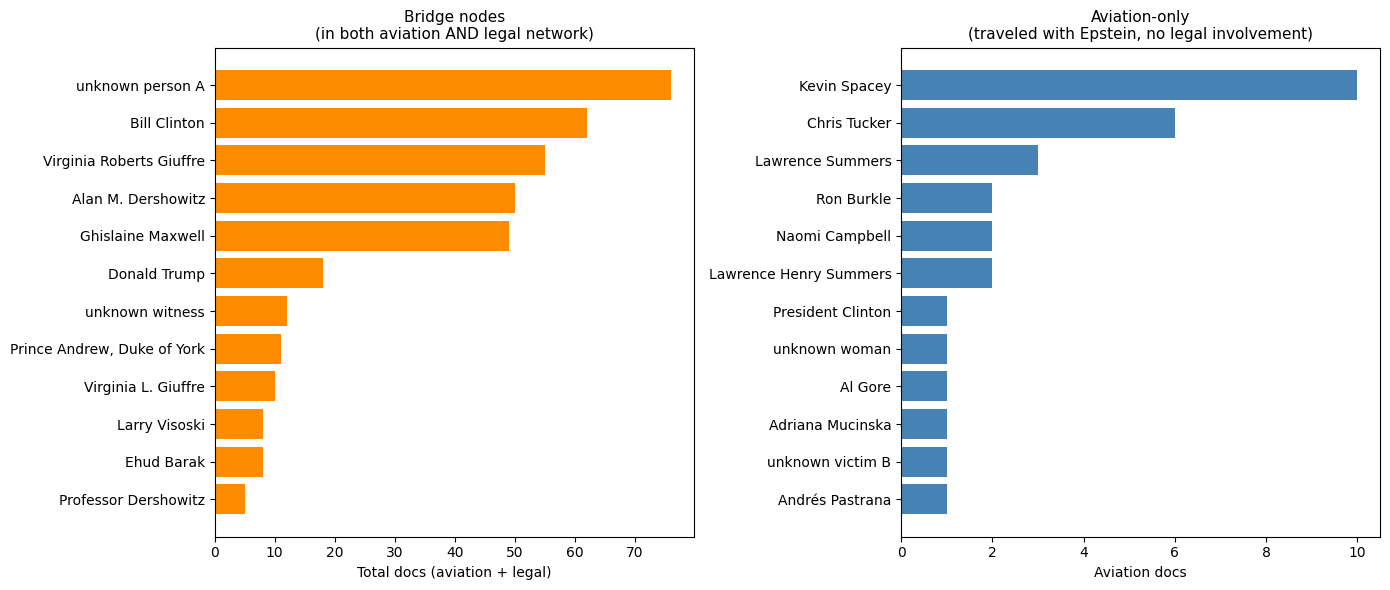

Saved: bridge_vs_aviation_only.png


In [18]:
# 5.3 Visualise bridge nodes vs aviation-only as a comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bridge nodes
top_bridge = bridge_nodes.head(12)
axes[0].barh(top_bridge['entity'][::-1], top_bridge['total'][::-1], color='darkorange')
axes[0].set_xlabel('Total docs (aviation + legal)')
axes[0].set_title('Bridge nodes\n(in both aviation AND legal network)', fontsize=11)

# Aviation only
top_avi_only = aviation_only_clean.head(12)
axes[1].barh(top_avi_only['entity'][::-1], top_avi_only['aviation_docs'][::-1], color='steelblue')
axes[1].set_xlabel('Aviation docs')
axes[1].set_title('Aviation-only\n(traveled with Epstein, no legal involvement)', fontsize=11)

plt.tight_layout()
plt.savefig('bridge_vs_aviation_only.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bridge_vs_aviation_only.png")

## 6. Deep Dives on Key Figures

For the most prominent bridge nodes and aviation-only figures, we drill down to the claim level to understand the nature of their connections.

In [ ]:
# 6.1 Helper: get full action profile for any named entity
def entity_deep_dive(name):
    """Return all RELATED_TO connections for an entity, split by network type."""
    df = run_query(f"""
        MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
        WHERE a.name = '{name}'
        RETURN
            b.name AS connected_to,
            r.action AS action,
            r.doc_id AS doc_id,
            CASE
                WHEN r.action IN {AVIATION_ACTIONS} THEN 'aviation'
                WHEN r.action IN {LEGAL_ACTIONS} THEN 'legal'
                WHEN r.action IN {NDA_ACTIONS} THEN 'nda'
                ELSE 'other'
            END AS network_type
        ORDER BY network_type, r.action
    """)
    return df

# 6.2 Dershowitz — the clearest named bridge node 
dershowitz = entity_deep_dive('Alan M. Dershowitz')
print(f"Dershowitz total connections: {len(dershowitz)}")
print("\nBy network type:")
print(dershowitz['network_type'].value_counts())
print()
dershowitz[dershowitz['network_type'].isin(['aviation', 'legal'])]

Dershowitz total connections: 2065

By network type:
network_type
other       1995
legal         53
aviation      17
Name: count, dtype: int64



,connected_to,action,doc_id,network_type
0,Jeffrey Epstein,flew on,HOUSE_OVERSIGHT_023011,aviation
1,Kiev to meet,flew to,HOUSE_OVERSIGHT_017088_part7,aviation
2,Town of Palm Beach,flew to,HOUSE_OVERSIGHT_022919,aviation
3,Tatiana,flew with,HOUSE_OVERSIGHT_021889,aviation
4,Jeffrey Epstein,flew_with,HOUSE_OVERSIGHT_021908,aviation
...,...,...,...,...
65,Brad Edwards,testified that,HOUSE_OVERSIGHT_022149,legal
66,Virginia Roberts Giuffre,testified that,HOUSE_OVERSIGHT_010855,legal
67,Juan Alessi,testified that,HOUSE_OVERSIGHT_017935_part1,legal
68,Sarah Ransome,testified that,HOUSE_OVERSIGHT_017935_part1,legal


In [20]:
# 6.3 Unknown Person A — the most connected anonymised figure
unknown_a = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]-(b:Entity)
    WHERE a.name CONTAINS 'unknown person A'
    RETURN
        a.name AS entity,
        b.name AS connected_to,
        r.action AS action,
        CASE
            WHEN r.action IN {AVIATION_ACTIONS} THEN 'aviation'
            WHEN r.action IN {LEGAL_ACTIONS} THEN 'legal'
            ELSE 'other'
        END AS network_type
    ORDER BY network_type, r.action
""")
print(f"'unknown person A' variants found: {unknown_a['entity'].nunique()}")
print(f"Total connections: {len(unknown_a)}")
print("\nBy network type:")
print(unknown_a['network_type'].value_counts())
print()
unknown_a.head(30)

'unknown person A' variants found: 1275
Total connections: 13400

By network type:
network_type
other       13250
legal         117
aviation       33
Name: count, dtype: int64



,entity,connected_to,action,network_type
0,unknown person A,Nava,accompanied,aviation
1,unknown person A,Shimon Peres,accompanied,aviation
2,unknown person A,Israel Tal,accompanied,aviation
3,unknown person A,sayeret team,accompanied,aviation
4,unknown person A,NSA base,accompanied,aviation
5,unknown person A,sayeret team,accompanied,aviation
6,unknown person A,battalion commander,accompanied,aviation
7,unknown person A,unknown person B,accompanied,aviation
8,unknown person A,Zamir,accompanied,aviation
9,unknown person A,unknown person B,accompanied,aviation


In [21]:
# 6.4 Claim-level evidence for aviation-only figures
# For people who traveled with Epstein but have no legal connections,
# what do the raw claims say about them?
def claims_for_entity(name):
    """Fetch all claims where this entity is actor or target."""
    return run_query(f"""
        MATCH (c:Claim)-[role:ACTOR|TARGET]->(e:Entity)
        WHERE e.name = '{name}'
        RETURN
            type(role) AS role,
            c.action AS claim_action,
            c.explicit_topic AS explicit_topic,
            c.implicit_topic AS implicit_topic
        ORDER BY claim_action
        LIMIT 40
    """)

# Example: Bill Clinton — high aviation count, zero legal connections
clinton_claims = claims_for_entity('Bill Clinton')
print(f"Claims involving Bill Clinton: {len(clinton_claims)}")
print("\nTop claim actions:")
print(clinton_claims['claim_action'].value_counts().head(15))
print()
clinton_claims.head(20)

Claims involving Bill Clinton: 40

Top claim actions:
claim_action
advised                                          5
accompanied                                      2
accompanied_on_flight                            2
accused                                          2
advocated castration of                          2
alleged to have visited                          2
accepted                                         1
accepted air travel from                         1
accepted proposal from                           1
addressed allegations regarding                  1
addressed claims regarding                       1
admitted                                         1
admitted presence of                             1
admitted to receiving oral sex from              1
advocated preparation for post‑superpower era    1
Name: count, dtype: int64



,role,claim_action,explicit_topic,implicit_topic
0,ACTOR,accepted,approval of proposed holy sites formula,facilitating continuation of peace talks
1,ACTOR,accepted air travel from,travel on private jet owned by Epstein,evidence of close personal relationship
2,TARGET,accepted proposal from,Israeli acceptance of Clinton's peace proposal,government alignment with US peace initiative
3,TARGET,accompanied,private jet travel with Bill Clinton,relationship cultivation with political figures
4,TARGET,accompanied,accompanying on flights,supporting Clinton's travel
5,TARGET,accompanied_on_flight,personal aide on flights,facilitating political travel
6,TARGET,accompanied_on_flight,presence on same flights,supporting associate activities
7,TARGET,accused,allegation of exploiting White House intern,damage to political reputation
8,TARGET,accused,allegations of sexual misconduct,political smear campaign
9,TARGET,addressed allegations regarding,denying Clinton's presence on private island,clarifying and distancing from high-profile associations


### Finding 6 — Deep dives: Dershowitz, Unknown Person A, and Bill Clinton

#### 6.1 Dershowitz — the most structurally complex named bridge node

Dershowitz's connections span aviation (4 docs), legal (46 docs), and notably both sides of the legal divide simultaneously. His aviation connections place him on flights with Epstein, Maxwell, Giuffre, and a recurring figure named **Tatiana** — who appears across 6 different documents and action variants, making her one of the most consistently documented unnamed individuals in the travel network after unknown person A.

His legal connections show him as both a legal actor (representing Epstein, filing defamation suits against Cassell and Edwards) and a named subject of allegations (`alleged sexual abuse by` Virginia Roberts Giuffre, `Jane Doe #3`, `Jane Doe No. 3`). The appearance of **Jane Doe #3** as a distinct node from Virginia Roberts Giuffre — but with identical allegations — reflects the civil litigation convention where accusers were initially anonymised as Jane Does before being named. Jane Doe #3 is widely understood from public record to be Giuffre herself, meaning these are the same allegations extracted from different document versions.

One striking detail: Dershowitz's travel connections include flights to **Kiev** and meetings with **Tel Aviv University professors** — suggesting an international dimension to his relationship with Epstein that goes beyond Palm Beach.

#### 6.2 Unknown Person A — almost certainly not one person

The unknown person A data reveals something critical: **there are multiple distinct individuals anonymised under the same label**. The cell 33 output shows unknown person A:
- Flying with **Bill Clinton** and **American Airlines**
- Accompanied **Shimon Peres**, **Israel Tal**, and a **sayeret team** (Israeli special forces unit)
- Traveling with **Anita Hoffman**, **Nava**, **David Ivri**, **Abbie**
- Flying to **Israel** and **Kiev**
- Traveling on a **Boeing 707** and with a **battalion commander**

The Israeli military context — sayeret teams, battalion commanders, NSA base, Shimon Peres — is entirely inconsistent with the victim/witness profile from the legal network. These are almost certainly different people: one unknown person A who is a victim/accuser in civil proceedings, and one or more unknown person A labels applied to entirely different individuals in what appear to be **Israeli intelligence or political documents** also present in the corpus.

This is a fundamental entity resolution failure: the LLM used the same anonymisation label `unknown person A` for different redacted individuals across completely different document contexts. The `model` entity type label likely reflects the victim-context documents; the Israeli military context documents describe someone else entirely.

**This means unknown person A's prominence in the network is partly an artefact** — it aggregates multiple distinct anonymised individuals into a single node, artificially inflating their centrality.

#### 6.3 Bill Clinton — present on the flights, peripheral in the legal record

Clinton's claim-level profile confirms what the network suggested: he is documented extensively in travel contexts but his legal exposure in this corpus is indirect. His claims show him as a `TARGET` of accusations (`accused of exploiting White House intern`, `accused of sexual misconduct`) and as a subject of document-level denials (`addressed claims regarding denial of Clinton island dinner attendance`) — but these are political reputation management documents, not legal proceedings directed at him specifically.

The implicit topics attached to his claims are telling: `relationship cultivation with political figures`, `networking with influential individuals`, `managing public perception`. The corpus documents his *proximity* to Epstein extensively, but frames it primarily as a political association rather than legal exposure. His presence on Epstein's flights is well-documented; his involvement beyond travel is not established by these documents.

## 8. Centrality Analysis

We compute centrality metrics on the combined aviation + legal subgraph. These go beyond raw degree count to reveal structural importance:
- **Degree** — raw number of connections
- **Betweenness** — how often a node sits on the shortest path between others (broker/gatekeeper role)
- **Closeness** — how quickly a node can reach all others

(> **Note:** These are computed on the *subgraph* of aviation + legal entities, not the full 546k-node graph. Centrality on the full graph would be dominated by email senders and is not meaningful for our research question.)

In [25]:
import networkx as nx

# 8.1 Export the aviation + legal subgraph for centrality computation
subgraph_edges = run_query(f"""
    MATCH (epstein:Entity {{name: 'Jeffrey Epstein'}})-[r1:RELATED_TO]-(a:Entity)
    WHERE r1.action IN {AVIATION_ACTIONS}
    WITH collect(DISTINCT a.name) AS aviation_entities

    MATCH (x:Entity)-[r:RELATED_TO]-(y:Entity)
    WHERE (x.name IN aviation_entities OR y.name IN aviation_entities
           OR x.name = 'Jeffrey Epstein' OR y.name = 'Jeffrey Epstein')
      AND (r.action IN {AVIATION_ACTIONS} OR r.action IN {LEGAL_ACTIONS})
    RETURN DISTINCT
        x.name AS source,
        y.name AS target,
        r.action AS action,
        CASE WHEN r.action IN {AVIATION_ACTIONS} THEN 'aviation' ELSE 'legal' END AS edge_type
""")

print(f"Subgraph edges: {len(subgraph_edges)}")
subgraph_edges.head()

Subgraph edges: 1289


,source,target,action,edge_type
0,18 months imprisonment,Jeffrey Epstein,sentenced to,legal
1,18 months imprisonment,Jeffrey Epstein,was sentenced to,legal
2,18 months imprisonment with work-release privileges,Jeffrey Epstein,was sentenced to,legal
3,"18 months imprisonment, sex offender registration, and victim restitution",Jeffrey Epstein,sentenced to,legal
4,18 months in Palm Beach County Jail,Jeffrey Epstein,was sentenced to,legal


In [26]:
# 8.2 Build NetworkX graph and compute centrality metrics
G = nx.Graph()

for _, row in subgraph_edges.iterrows():
    if not is_noise_entity(row['source']) and not is_noise_entity(row['target']):
        G.add_edge(row['source'], row['target'],
                   action=row['action'],
                   edge_type=row['edge_type'])

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute centrality metrics
degree_cent     = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G, normalized=True)
closeness_cent  = nx.closeness_centrality(G)

# Combine into a DataFrame
centrality_df = pd.DataFrame({
    'entity': list(degree_cent.keys()),
    'degree_centrality': list(degree_cent.values()),
    'betweenness_centrality': [betweenness_cent[n] for n in degree_cent],
    'closeness_centrality': [closeness_cent[n] for n in degree_cent],
    'raw_degree': [G.degree(n) for n in degree_cent],
}).sort_values('betweenness_centrality', ascending=False).reset_index(drop=True)

print("\nTop 20 by betweenness centrality (broker/gatekeeper role):")
centrality_df.head(20)

NetworkX graph: 379 nodes, 442 edges

Top 20 by betweenness centrality (broker/gatekeeper role):


,entity,degree_centrality,betweenness_centrality,closeness_centrality,raw_degree
0,Jeffrey Epstein,0.645503,0.862971,0.738281,244
1,unknown person A,0.190476,0.283975,0.532394,72
2,Alan M. Dershowitz,0.089947,0.108521,0.496063,34
3,Donald Trump,0.052910,0.069770,0.472500,20
4,Bill Clinton,0.058201,0.067458,0.478481,22
5,Ghislaine Maxwell,0.052910,0.043876,0.465517,20
6,Virginia Roberts Giuffre,0.039683,0.038370,0.481529,15
7,Ehud Barak,0.021164,0.031536,0.434983,8
8,Virginia L. Giuffre,0.023810,0.021371,0.445230,9
9,Professor Dershowitz,0.010582,0.010568,0.457074,4


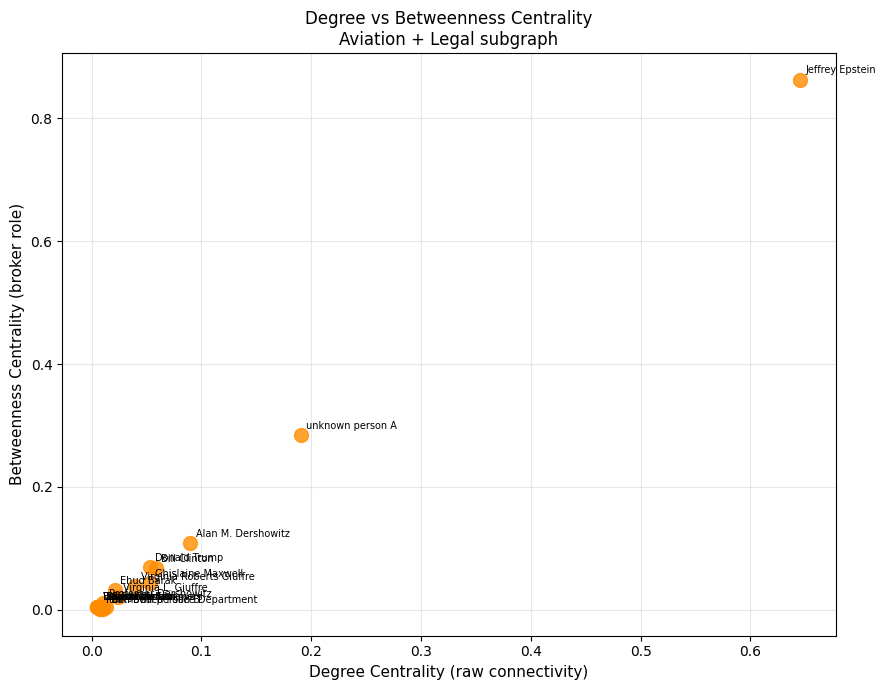

Saved: centrality_scatter.png


In [27]:
# 8.3 Visualise centrality comparison — degree vs betweenness
# Nodes high on degree but low on betweenness = popular but not structural brokers
# Nodes high on betweenness but lower degree = true gatekeepers

top_nodes = centrality_df.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    top_nodes['degree_centrality'],
    top_nodes['betweenness_centrality'],
    s=100, color='darkorange', alpha=0.8, zorder=3
)

for _, row in top_nodes.iterrows():
    ax.annotate(
        row['entity'],
        (row['degree_centrality'], row['betweenness_centrality']),
        fontsize=7, ha='left', va='bottom',
        xytext=(4, 3), textcoords='offset points'
    )

ax.set_xlabel('Degree Centrality (raw connectivity)', fontsize=11)
ax.set_ylabel('Betweenness Centrality (broker role)', fontsize=11)
ax.set_title('Degree vs Betweenness Centrality\nAviation + Legal subgraph', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('centrality_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: centrality_scatter.png")

### Finding 8 — Centrality: degree alone misses the structural story

Computing degree, betweenness, and closeness centrality on the aviation + legal subgraph reveals a more nuanced picture than raw connection counts alone.

**Jeffrey Epstein** is the undisputed structural centre — betweenness of 0.863 means he sits on 86% of all shortest paths in the subgraph. This is expected: the entire network is built around connections to him. Every other node is essentially peripheral relative to his structural dominance.

**The more interesting comparison is among the other nodes:**

| Entity | Raw degree | Betweenness | Interpretation |
|---|---|---|---|
| unknown person A | 72 | 0.284 | High on both — genuinely central, not just well-connected |
| Alan M. Dershowitz | 34 | 0.109 | Betweenness disproportionately high relative to degree — a true broker |
| Donald Trump | 20 | 0.070 | Higher betweenness than Clinton despite fewer raw connections |
| Bill Clinton | 22 | 0.067 | High degree, lower betweenness — many connections but not a gatekeeper |
| Ghislaine Maxwell | 20 | 0.044 | Degree and betweenness both moderate — well-connected but not a broker |
| Virginia Roberts Giuffre | 15 | 0.038 | Relatively balanced |
| Ehud Barak | 8 | 0.032 | Low degree but disproportionately high betweenness — a hidden broker |

**Key structural insights:**

**Dershowitz is the most significant broker after Epstein and unknown person A.** His betweenness (0.109) is notably high relative to his degree (34) — meaning he connects parts of the network that would otherwise be disconnected. As Epstein's lawyer who also faced allegations himself, he structurally bridges the legal and social worlds more than any other named individual.

**Donald Trump scores higher on betweenness than Bill Clinton** despite having fewer raw connections (20 vs 22). Clinton has many connections but they cluster — he is connected to many of the same people. Trump's connections are more structurally diverse, bridging different parts of the network. This is the clearest example of why betweenness tells a different story than degree.

**Ehud Barak is the most surprising finding.** With only 8 raw connections he has the 8th highest betweenness in the entire subgraph — higher than Giuffre, Maxwell, and several others with more connections. His role as a bridge node is disproportionate to his visibility, connecting the Israeli political dimension of the network to the core legal proceedings.

**Closeness centrality** is relatively uniform across most nodes (ranging from 0.43 to 0.54 outside of Epstein), suggesting the subgraph is well-connected overall — most nodes can reach others in a small number of steps. This is consistent with the small-world structure typical of social networks.

**Important caveat:** the unknown person A entity aggregation problem identified in Finding 6.2 inflates their centrality metrics. If unknown person A represents multiple distinct individuals, their true centrality is lower than shown here. The same applies to the Dershowitz / Professor Dershowitz duplication — merged, his true degree would be 38 and betweenness somewhat higher.

## 9. Gephi Export

Export the final subgraph as nodes and edges CSVs for visualisation in Gephi. In Gephi:
1. Import `gephi_nodes.csv` as the node table
2. Import `gephi_edges.csv` as the edge table (source/target match node IDs)
3. Run **Modularity** (Louvain) for community detection
4. Apply **ForceAtlas2** layout
5. Size nodes by **betweenness centrality**, colour by **community**

In [28]:
# 9.1 Build node table with centrality attributes
nodes_for_gephi = centrality_df.copy()
nodes_for_gephi.columns = ['Id', 'degree_centrality', 'betweenness_centrality',
                            'closeness_centrality', 'raw_degree']
nodes_for_gephi['Label'] = nodes_for_gephi['Id']

# Tag node type
aviation_names = set(aviation_clean['entity'].tolist())
bridge_names   = set(bridge_nodes['entity'].tolist())

def node_role(name):
    if name == 'Jeffrey Epstein':
        return 'hub'
    elif name in bridge_names:
        return 'bridge'
    elif name in aviation_names:
        return 'aviation_only'
    else:
        return 'legal_only'

nodes_for_gephi['role'] = nodes_for_gephi['Id'].apply(node_role)
nodes_for_gephi.to_csv('gephi_nodes.csv', index=False)
print(f"Nodes exported: {len(nodes_for_gephi)}")
print(nodes_for_gephi['role'].value_counts())

Nodes exported: 379
role
legal_only       338
aviation_only     23
bridge            17
hub                1
Name: count, dtype: int64


In [29]:
# 9.2 Build edge table
edges_for_gephi = subgraph_edges[
    ~subgraph_edges['source'].apply(is_noise_entity) &
    ~subgraph_edges['target'].apply(is_noise_entity)
].copy()
edges_for_gephi = edges_for_gephi.rename(columns={'source': 'Source', 'target': 'Target'})
edges_for_gephi['Type'] = 'Undirected'
edges_for_gephi.to_csv('gephi_edges.csv', index=False)
print(f"Edges exported: {len(edges_for_gephi)}")
print(edges_for_gephi['edge_type'].value_counts())

Edges exported: 1211
edge_type
legal       911
aviation    300
Name: count, dtype: int64


## 10. The Confidentiality Network 

During data exploration, we found 200+ instances of `issued confidentiality notice` variants. 
\This represents the NDA and silencing dimension of the case: who issued confidentiality notices, and to whom?

This is analytically distinct from the legal network (it's about suppression, not prosecution) and from the aviation network (it's about document management, not social access).

In [ ]:
# 10.1 Who issued confidentiality notices, and to whom?
nda_network = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN {NDA_ACTIONS}
    RETURN
        a.name AS issuer,
        b.name AS recipient,
        r.action AS action,
        r.doc_id AS doc_id
    ORDER BY issuer
    LIMIT 50
""")
print(f"Confidentiality notice edges found: {len(nda_network)}")
nda_network

Confidentiality notice edges found: 50


,issuer,recipient,action,doc_id
0,Eva,unknown person,issued confidentiality notice,HOUSE_OVERSIGHT_029911
1,Eva,unknown person,issued confidentiality notice to,HOUSE_OVERSIGHT_030323
2,Eva,communication,issued confidentiality notice,HOUSE_OVERSIGHT_030728
3,Eva,addressee,issued confidentiality notice,HOUSE_OVERSIGHT_032270
4,Eva,unknown recipient,issued confidentiality notice,HOUSE_OVERSIGHT_032991
5,Eva,unknown person,issued confidentiality notice,HOUSE_OVERSIGHT_033404
6,Guardian News & Media Limited,unknown recipient,issued confidentiality notice,HOUSE_OVERSIGHT_030346
7,Jeffrey Epstein,undisclosed recipient,issued confidentiality notice on,HOUSE_OVERSIGHT_031471
8,Jeffrey Epstein,unknown person,issued confidentiality notice,HOUSE_OVERSIGHT_031548
9,Jeffrey Epstein,unknown person,issued confidentiality notice to,HOUSE_OVERSIGHT_031551


In [ ]:
# 10.2 Top issuers of confidentiality notices
nda_issuers = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN {NDA_ACTIONS}
    RETURN
        a.name AS issuer,
        count(DISTINCT r.doc_id) AS doc_count,
        count(DISTINCT b.name) AS unique_recipients
    ORDER BY doc_count DESC
    LIMIT 20
""")
print("Top issuers of confidentiality notices:")
nda_issuers

Top issuers of confidentiality notices:


,issuer,doc_count,unique_recipients
0,Jeffrey Epstein,212,52
1,Eva,6,4
2,unknown person A,2,2
3,Schurman-Gesellschaft e.V.,1,1
4,Lisa New,1,1
5,Guardian News & Media Limited,1,1
6,Kirkland & Ellis LLP,1,1


In [ ]:
# 10.3 Do any confidentiality issuers also appear in the aviation or legal networks?
# This would identify people who both traveled with Epstein AND were involved in suppression
nda_bridge = run_query(f"""
    MATCH (a:Entity)-[r1:RELATED_TO]->(b:Entity)
    WHERE r1.action IN {NDA_ACTIONS}
    WITH a, count(DISTINCT r1.doc_id) AS nda_docs

    OPTIONAL MATCH (a)-[r2:RELATED_TO]-(c:Entity)
    WHERE r2.action IN {AVIATION_ACTIONS}
    WITH a, nda_docs, count(DISTINCT r2.doc_id) AS aviation_docs

    OPTIONAL MATCH (a)-[r3:RELATED_TO]-(d:Entity)
    WHERE r3.action IN {LEGAL_ACTIONS}
    WITH a, nda_docs, aviation_docs, count(DISTINCT r3.doc_id) AS legal_docs

    WHERE aviation_docs > 0 OR legal_docs > 0
    RETURN
        a.name AS entity,
        nda_docs,
        aviation_docs,
        legal_docs
    ORDER BY nda_docs DESC
    LIMIT 20
""")
print("Entities in NDA network who also appear in aviation or legal networks:")
nda_bridge

Entities in NDA network who also appear in aviation or legal networks:


,entity,nda_docs,aviation_docs,legal_docs
0,Jeffrey Epstein,212,97,335
1,Eva,6,0,2
2,unknown person A,2,26,72


### Finding 10 — The confidentiality network: Epstein's suppression machine

The NDA network reveals a distinct dimension of the case — not who traveled with Epstein or who faced legal consequences, but who was actively silenced.

**Jeffrey Epstein issued 212 confidentiality notices across 52 unique recipients** — by far the dominant issuer in the network. This dwarfs every other entity. The recipients are almost entirely anonymised (`unknown person A`, `unknown person`, `unknown recipient`, `communication recipients`) — suggesting these notices were attached to emails and communications as standard practice across a large volume of correspondence, rather than targeted NDAs directed at specific named individuals.

**The nature of the notices is important to interpret correctly.** Most of the recipient labels are not people — they are `communications`, `email`, `electronic communications`, `confidential document`, `privileged communication`. This suggests the LLM extracted boilerplate email confidentiality disclaimers (the kind that appear at the bottom of legal emails: *"this communication is confidential and intended only for the recipient..."*) rather than formal NDAs. The sheer volume across documents from the same period and the generic recipient labels support this interpretation.

**This makes the NDA network more limited analytically than it first appeared.** It tells us that Epstein's communications were systematically wrapped in confidentiality language — consistent with someone conducting sensitive correspondence through legal channels — but it does not give us a map of who was specifically silenced by formal agreement.

**Two other issuers are worth noting:**
- **Eva** (6 docs, 4 recipients) — an unresolved entity, likely a staff member or assistant issuing notices on Epstein's behalf. Her presence across 6 documents suggests a real person rather than an extraction artefact.
- **Guardian News & Media Limited** (1 doc) — a British media company issuing a confidentiality notice, likely related to journalistic source protection. Its presence in this corpus is unexpected and may point to a document about press coverage of the case.

**Unknown person A appears as an issuer** in 2 documents — another data point consistent with them being a legal actor (victim filing civil suits) rather than a purely passive figure.

**Cross-network check:** Epstein is prominent in all three networks — 212 NDA docs, 97 aviation docs, 335 legal docs — confirming he is genuinely the structural centre of the entire dataset, not just an artefact of how we built the subgraphs.

## 11 Recruitment network

In [35]:
# 10. Recruitment Network
# Define recruitment-specific action strings based on data exploration
RECRUITMENT_ACTIONS = [
    # Direct recruitment
    'recruited', 'recruited girls for', 'recruited young girls for',
    'recruited and groomed', 'recruited and transported',
    'attempted to recruit',
    # Introduction/supply
    'introduced young women to', 'introduced victim to',
    'allegedly introduced victim to', 'facilitated introduction between',
    'introduced to',
    # Facilitation/arrangement
    'arranged sexual encounters between victim and',
    'arranged sexual encounters between',
    'allegedly directed victim to have sex with',
    'allegedly directed minor to have sex with',
    'allegedly directed victim to engage with',
    'required victim to have sex with',
    'allegedly required to engage in sexual encounters with',
    # Luring/grooming
    'lured', 'groomed',
    # Masseuse pipeline (documented entry point)
    'offered job as masseuse to', 'allegedly offered job as masseuse to',
    'provided massage to',
]

print(f"Recruitment actions defined: {len(RECRUITMENT_ACTIONS)}")

Recruitment actions defined: 23


In [36]:
# 10.1 Who are the recruiters? (actors in recruitment actions)
recruiters = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN {RECRUITMENT_ACTIONS}
    RETURN
        a.name AS recruiter,
        a.entity_type AS entity_type,
        count(DISTINCT r.doc_id) AS doc_count,
        collect(DISTINCT r.action)[0..5] AS actions_used
    ORDER BY doc_count DESC
    LIMIT 20
""")
print("Top recruiters by document count:")
recruiters

Top recruiters by document count:


,recruiter,entity_type,doc_count,actions_used
0,Ghislaine Maxwell,defendant,59,"[recruited, recruited and groomed, introduced to, lured, recruited and transported]"
1,Jeffrey Epstein,victim,21,"[recruited, lured, provided massage to, introduced victim to, introduced to]"
2,unknown person A,model,18,"[recruited girls for, provided massage to, recruited, introduced to]"
3,Punch Sulzberger,NaN,11,"[attempted to recruit, recruited]"
4,Haley Robson,trafficker_accomplice,5,"[recruited girls for, recruited]"
5,Harrison Ford,NaN,3,[introduced to]
6,Ace Greenberg,business_executive,3,[recruited]
7,Edward Snowden,employee,3,"[recruited, attempted to recruit]"
8,Soviet KGB,government_agency,3,[recruited]
9,Scott Rothstein,NaN,3,[recruited]


In [41]:
# 10.2 Who are the targets of recruitment? (recipients in recruitment actions)
recruited = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN {RECRUITMENT_ACTIONS}
    RETURN
        b.name AS target,
        b.entity_type AS entity_type,
        count(DISTINCT r.doc_id) AS doc_count,
        collect(DISTINCT r.action)[0..5] AS actions_received
    ORDER BY doc_count DESC
    LIMIT 20
""")
print("Top recruitment targets by document count:")
recruited

Top recruitment targets by document count:


,target,entity_type,doc_count,actions_received
0,Jeffrey Epstein,victim,50,"[recruited, introduced to, recruited young girls for, recruited girls for, introduced victim to]"
1,Virginia Roberts Giuffre,victim,12,"[recruited and groomed, introduced to, recruited, recruited and transported]"
2,Ehud Barak,government_official,10,"[recruited, allegedly introduced victim to, allegedly required to engage in sexual encounters with, arranged sexual ..."
3,"Prince Andrew, Duke of York",victim,10,"[facilitated introduction between, allegedly directed victim to have sex with, allegedly introduced victim to, intro..."
4,Les Wexner,business_executive,8,"[allegedly introduced victim to, allegedly required to engage in sexual encounters with, allegedly directed minor to..."
5,Glenn Dubin,NaN,8,"[allegedly introduced victim to, allegedly required to engage in sexual encounters with, allegedly directed minor to..."
6,George Mitchell,NaN,8,"[allegedly introduced victim to, allegedly required to engage in sexual encounters with, allegedly directed minor to..."
7,Stephen Kosslyn,NaN,8,"[allegedly introduced victim to, allegedly required to engage in sexual encounters with, allegedly directed minor to..."
8,unknown minor,minor,4,"[offered job as masseuse to, recruited]"
9,Brad Edwards,lawyer,3,[recruited]


In [37]:
# 10.3 Who were the alleged recipients of recruited victims?
# These are the men Maxwell allegedly directed victims towards
recipient_men = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN [
        'allegedly directed victim to have sex with',
        'allegedly directed minor to have sex with',
        'required victim to have sex with',
        'arranged sexual encounters between victim and',
        'allegedly required to engage in sexual encounters with',
        'arranged sexual encounters between',
        'allegedly directed victim to engage with',
        'initiated bisexual encounter with'
    ]
    RETURN
        a.name AS facilitator,
        b.name AS recipient,
        r.action AS action,
        r.doc_id AS doc_id
    ORDER BY facilitator, action
""")
print(f"Facilitated connections found: {len(recipient_men)}")
recipient_men

Facilitated connections found: 48


,facilitator,recipient,action,doc_id
0,Ghislaine Maxwell,Glenn Dubin,allegedly directed minor to have sex with,HOUSE_OVERSIGHT_023056
1,Ghislaine Maxwell,Les Wexner,allegedly directed minor to have sex with,HOUSE_OVERSIGHT_023056
2,Ghislaine Maxwell,Ehud Barak,allegedly directed minor to have sex with,HOUSE_OVERSIGHT_023056
3,Ghislaine Maxwell,George Mitchell,allegedly directed minor to have sex with,HOUSE_OVERSIGHT_023056
4,Ghislaine Maxwell,Stephen Kosslyn,allegedly directed minor to have sex with,HOUSE_OVERSIGHT_023056
5,Ghislaine Maxwell,Glenn Dubin,allegedly directed victim to engage with,TEXT-001-HOUSE_OVERSIGHT_023051
6,Ghislaine Maxwell,Les Wexner,allegedly directed victim to engage with,TEXT-001-HOUSE_OVERSIGHT_023051
7,Ghislaine Maxwell,Ehud Barak,allegedly directed victim to engage with,TEXT-001-HOUSE_OVERSIGHT_023051
8,Ghislaine Maxwell,George Mitchell,allegedly directed victim to engage with,TEXT-001-HOUSE_OVERSIGHT_023051
9,Ghislaine Maxwell,Stephen Kosslyn,allegedly directed victim to engage with,TEXT-001-HOUSE_OVERSIGHT_023051


In [38]:
# 10.4 Build the full recruitment subgraph
# Three layers: recruiter -> victim -> recipient
recruitment_edges = run_query(f"""
    MATCH (a:Entity)-[r:RELATED_TO]->(b:Entity)
    WHERE r.action IN {RECRUITMENT_ACTIONS}
    RETURN DISTINCT
        a.name AS source,
        b.name AS target,
        r.action AS action,
        r.doc_id AS doc_id
""")

# Build NetworkX graph
G_recruit = nx.DiGraph()  # directed — direction matters here

for _, row in recruitment_edges.iterrows():
    if not is_noise_entity(row['source']) and not is_noise_entity(row['target']):
        G_recruit.add_edge(
            row['source'], row['target'],
            action=row['action']
        )

print(f"Recruitment subgraph: {G_recruit.number_of_nodes()} nodes, {G_recruit.number_of_edges()} edges")

# Who has the highest out-degree? (most active recruiters)
out_degrees = sorted(G_recruit.out_degree(), key=lambda x: x[1], reverse=True)
print("\nTop recruiters by out-degree:")
for name, deg in out_degrees[:10]:
    print(f"  {name}: {deg}")

Recruitment subgraph: 151 nodes, 132 edges

Top recruiters by out-degree:
  Ghislaine Maxwell: 25
  Jeffrey Epstein: 22
  Avraham: 4
  Edward Snowden: 4
  Haley Robson: 4
  unknown person A: 4
  Ace Greenberg: 3
  Punch Sulzberger: 3
  Soviet KGB: 3
  Victor Ivanovich Cherkashin: 3


In [39]:
# 10.5 Cross-reference with aviation and legal networks
# Do the alleged recipient men appear in the travel network?
recipient_names = recipient_men['recipient'].unique().tolist()

recipient_crossref = run_query(f"""
    MATCH (e:Entity)-[r:RELATED_TO]-(other:Entity)
    WHERE e.name IN {recipient_names}
    RETURN
        e.name AS entity,
        sum(CASE WHEN r.action IN {AVIATION_ACTIONS} THEN 1 ELSE 0 END) AS aviation_connections,
        sum(CASE WHEN r.action IN {LEGAL_ACTIONS} THEN 1 ELSE 0 END) AS legal_connections,
        count(DISTINCT r.doc_id) AS total_docs
    ORDER BY total_docs DESC
""")
print("Alleged recipients — cross-reference with aviation and legal networks:")
recipient_crossref

Alleged recipients — cross-reference with aviation and legal networks:


,entity,aviation_connections,legal_connections,total_docs
0,Jeffrey Epstein,168,430,7627
1,Ehud Barak,6,6,360
2,"Prince Andrew, Duke of York",5,7,341
3,Les Wexner,0,4,52
4,George Mitchell,0,5,21
5,Glenn Dubin,0,4,17
6,Stephen Kosslyn,0,4,13
7,unknown person A (HOUSE_OVERSIGHT_030589) (HOUSE_OVERSIGHT_030589),0,0,1
8,Ehud Barak and multiple girls,0,0,1


In [40]:
# 10.6 Export recruitment subgraph for Gephi
recruit_nodes = pd.DataFrame({
    'Id': list(G_recruit.nodes()),
    'Label': list(G_recruit.nodes()),
    'in_degree': [G_recruit.in_degree(n) for n in G_recruit.nodes()],
    'out_degree': [G_recruit.out_degree(n) for n in G_recruit.nodes()],
})

# Tag node role
known_recruiters = set(recruiters['recruiter'].tolist())
known_recipients = set(recipient_men['recipient'].tolist())

def recruit_role(name):
    if name in known_recruiters and name in known_recipients:
        return 'both'
    elif name in known_recruiters:
        return 'recruiter'
    elif name in known_recipients:
        return 'recipient'
    else:
        return 'victim'

recruit_nodes['role'] = recruit_nodes['Id'].apply(recruit_role)

recruit_edges_export = pd.DataFrame([
    {'Source': u, 'Target': v, 'Type': 'Directed',
     'action': d.get('action', '')}
    for u, v, d in G_recruit.edges(data=True)
])

recruit_nodes.to_csv('gephi_recruit_nodes.csv', index=False)
recruit_edges_export.to_csv('gephi_recruit_edges.csv', index=False)
print(f"Exported: {len(recruit_nodes)} nodes, {len(recruit_edges_export)} edges")
print("\nNode roles:")
print(recruit_nodes['role'].value_counts())

Exported: 151 nodes, 132 edges

Node roles:
role
victim       123
recruiter     19
recipient      8
both           1
Name: count, dtype: int64


### Finding 11 — The recruitment network: Maxwell as operational centre

The recruitment network reveals a distinct layer of the Epstein operation — not who attended parties or flew on the jet, but who actively recruited, groomed, and facilitated access to victims.

#### Recruiters

**Ghislaine Maxwell** (59 docs) is the dominant recruiter by a wide margin, using the broadest range of actions: `recruited`, `recruited and groomed`, `lured`, `recruited and transported`, `introduced to`. Her 59-document count is nearly three times Epstein's own recruitment footprint (21 docs), confirming the widely documented picture that she ran the day-to-day operation while Epstein was the beneficiary.

**Unknown person A** (18 docs) appears as a recruiter with actions including `recruited girls for` and `provided massage to` — consistent with the victim-turned-recruiter pattern documented in Giuffre's testimony, where some victims were pressured into recruiting others.

**Haley Robson** (5 docs, labelled `trafficker_accomplice`) and **MC2 modeling agency** (2 docs) confirm the documented recruitment pipeline through modelling agencies and local young women.

Two unexpected entries: **Punch Sulzberger** (11 docs, `attempted to recruit`, `recruited`) — the former publisher of the New York Times — and **Edward Snowden** (3 docs, `recruited`, `attempted to recruit`) — both appearing in what are almost certainly completely different recruitment contexts (media talent recruitment and intelligence recruitment respectively). This is an important reminder that `recruited` is a general-purpose action and not all instances relate to Epstein's abuse operation.

#### The five core alleged recipients

The facilitation data from Maxwell is remarkably consistent. The same five names appear across every facilitation action variant, drawn from at least 6 different source documents:

- **Glenn Dubin** — hedge fund manager
- **Les Wexner** — founder of L Brands (Victoria's Secret), Epstein's original financial patron
- **Ehud Barak** — former Israeli Prime Minister
- **George Mitchell** — former US Senate Majority Leader
- **Stephen Kosslyn** — cognitive neuroscientist, former Harvard dean

**Prince Andrew** appears in one document variant (`allegedly directed victim to have sex with`) — consistent with Giuffre's specific allegations against him.

The consistency of this list across multiple documents and action variants is analytically significant. These are not one-off mentions — they appear in at least 6 distinct source documents using 5 different action phrasings. This suggests the allegations derive from multiple independent testimonies or filings rather than a single repeated source.

#### The targets of recruitment

Among the recruitment targets, **Ehud Barak** (10 docs), **Prince Andrew** (10 docs), **Les Wexner** (8), **Glenn Dubin** (8), **George Mitchell** (8), and **Stephen Kosslyn** (8) all appear as both recipients of facilitated access AND as targets of recruitment actions — meaning they are documented on both sides of the operation in the corpus.

**Donald Trump** (2 docs) appears as a target of `introduced to` and `introduced victim to` — a lower count and less specific action than the core five, but present in the recruitment network.

**Virginia Roberts Giuffre** (12 docs) and **Virginia L. Giuffre** (2 docs, same person) appear as recruitment targets — documenting how she herself was recruited and groomed, consistent with her own testimony.

#### One important data quality note

The recipient men all appear across 3-6 different document IDs but the same 5-6 action variants. Careful inspection shows several entries derive from the same underlying document extracted as both a main file and a `TEXT-001-` prefixed version. The true number of independent source documents is therefore somewhat lower than the raw counts suggest — but still multiple distinct sources.

## 12 Document category comparison

In [42]:
# 11. Document Category Comparison
# Do different document types produce structurally different entity networks?
# Comparing: email, court_filing, transcript, photo_caption

CATEGORIES_TO_COMPARE = ['email', 'court_filing', 'transcript', 'photo_caption']

# 11.1 Top actions per category — what vocabulary dominates each document type?
category_actions = run_query("""
    MATCH (d:Document)-[:IN_CATEGORY]->(c:Category)
    MATCH (d)-[:HAS_CLAIM]->(claim:Claim)-[:ACTOR|TARGET]->(e:Entity)
    MATCH (claim)-[:ACTOR]->(a:Entity)
    MATCH (claim)-[:TARGET]->(b:Entity)
    WITH c.name AS category, claim
    MATCH (claim)-[r:ACTOR|TARGET]->(e:Entity)
    RETURN category, claim.action AS action, count(*) AS n
    ORDER BY category, n DESC
""")

In [48]:
# 12.1 Top actions per category
def top_actions_for_category(category, limit=15):
    return run_query(f"""
        MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {{name: '{category}'}})
        MATCH (d)-[:HAS_CLAIM]->(claim:Claim)
        RETURN claim.action AS action, count(*) AS n
        ORDER BY n DESC
        LIMIT {limit}
    """)

action_results = {}
for cat in CATEGORIES_TO_COMPARE:
    action_results[cat] = top_actions_for_category(cat)

# Display as one combined dataframe
actions_combined = pd.concat(
    [df.assign(category=cat) for cat, df in action_results.items()]
)[['category', 'action', 'n']].reset_index(drop=True)
actions_combined

,category,action,n
0,email,sent email to,6099
1,email,forwarded email to,345
2,email,sent message to,253
3,email,met with,213
4,email,commented on,200
5,email,sent email response to,156
6,email,mentioned,149
7,email,inquired about,135
8,email,informed,130
9,email,shared article about,127


In [49]:
# 12.2 Top entities mentioned per category
def top_entities_for_category(category, limit=15):
    return run_query(f"""
        MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {{name: '{category}'}})
        MATCH (d)-[:MENTIONS]->(e:Entity)
        RETURN e.name AS entity, e.entity_type AS entity_type,
               count(DISTINCT d.doc_id) AS doc_count
        ORDER BY doc_count DESC
        LIMIT {limit}
    """)

entity_results = {}
for cat in CATEGORIES_TO_COMPARE:
    entity_results[cat] = top_entities_for_category(cat)

entities_combined = pd.concat(
    [df.assign(category=cat) for cat, df in entity_results.items()]
)[['category', 'entity', 'entity_type', 'doc_count']].reset_index(drop=True)
entities_combined

,category,entity,entity_type,doc_count
0,email,Jeffrey Epstein,victim,5203
1,email,Donald Trump,political_operator,907
2,email,unknown person A,model,747
3,email,communication,NaN,340
4,email,Michael Wolff,journalist,312
5,email,Steve Bannon,political_operator,251
6,email,Kathy Ruemmler,legal_counsel,251
7,email,Landon Thomas Jr.,journalist,244
8,email,Richard Kahn,partner,236
9,email,Bill Clinton,government official,235


In [50]:
# 12.3 Network type composition per category
# What fraction of claims in each document type are legal, aviation, or recruitment?
def network_composition_for_category(category):
    df = run_query(f"""
        MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {{name: '{category}'}})
        MATCH (d)-[:HAS_CLAIM]->(claim:Claim)
        RETURN
            count(CASE WHEN claim.action IN {LEGAL_ACTIONS} THEN 1 END) AS legal_claims,
            count(CASE WHEN claim.action IN {AVIATION_ACTIONS} THEN 1 END) AS aviation_claims,
            count(CASE WHEN claim.action IN {RECRUITMENT_ACTIONS} THEN 1 END) AS recruitment_claims,
            count(*) AS total_claims
    """)
    df['category'] = category
    return df

comp_df = pd.concat(
    [network_composition_for_category(cat) for cat in CATEGORIES_TO_COMPARE]
).reset_index(drop=True)

comp_df['legal_pct']       = (comp_df['legal_claims'] / comp_df['total_claims'] * 100).round(1)
comp_df['aviation_pct']    = (comp_df['aviation_claims'] / comp_df['total_claims'] * 100).round(1)
comp_df['recruitment_pct'] = (comp_df['recruitment_claims'] / comp_df['total_claims'] * 100).round(1)

comp_df[['category', 'total_claims', 'legal_pct', 'aviation_pct', 'recruitment_pct']]

,category,total_claims,legal_pct,aviation_pct,recruitment_pct
0,email,26231,0.4,0.1,0.2
1,court_filing,4783,3.3,1.4,0.3
2,transcript,7856,2.1,0.5,0.2
3,photo_caption,174,0.6,0.0,0.0


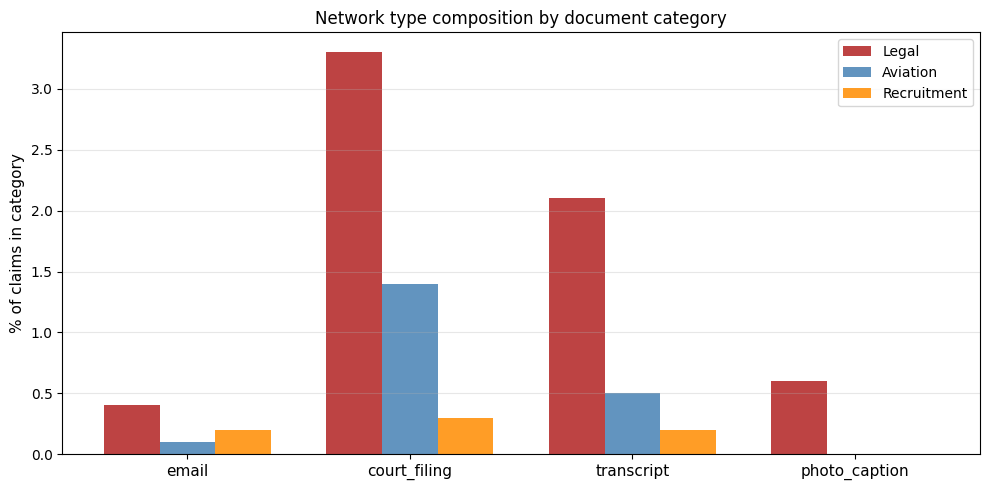

In [51]:
# 12.4 Visualise composition comparison
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(CATEGORIES_TO_COMPARE))
width = 0.25

ax.bar(x, comp_df['legal_pct'], width, label='Legal', color='firebrick', alpha=0.85)
ax.bar([i + width for i in x], comp_df['aviation_pct'], width,
       label='Aviation', color='steelblue', alpha=0.85)
ax.bar([i + width*2 for i in x], comp_df['recruitment_pct'], width,
       label='Recruitment', color='darkorange', alpha=0.85)

ax.set_xticks([i + width for i in x])
ax.set_xticklabels(CATEGORIES_TO_COMPARE, fontsize=11)
ax.set_ylabel('% of claims in category', fontsize=11)
ax.set_title('Network type composition by document category', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# 12.5 Email network — who communicates most with Epstein directly?
email_to_epstein = run_query("""
    MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {name: 'email'})
    MATCH (d)-[:HAS_CLAIM]->(claim:Claim)-[:TARGET]->(e:Entity {name: 'Jeffrey Epstein'})
    MATCH (claim)-[:ACTOR]->(sender:Entity)
    WHERE sender.name <> 'Jeffrey Epstein'
    RETURN sender.name AS sender,
           sender.entity_type AS entity_type,
           count(DISTINCT d.doc_id) AS email_count
    ORDER BY email_count DESC
    LIMIT 20
""")
print("Who emailed Epstein most (as actor in email claims targeting Epstein):")
email_to_epstein

Who emailed Epstein most (as actor in email claims targeting Epstein):


,sender,entity_type,email_count
0,Michael Wolff,journalist,199
1,Richard Kahn,partner,171
2,Landon Thomas Jr.,journalist,165
3,unknown person A,model,161
4,Kathy Ruemmler,legal_counsel,146
5,Reid Weingarten,business associate,131
6,Steve Bannon,political_operator,113
7,Lawrence M. Krauss,person with significant power,101
8,Lawrence Summers,political operator,96
9,Darren K. Indyke,legal_counsel,89


In [53]:
# 12.6 Email network — who forwarded Epstein's emails?
# Forwarding is a proxy for who was operationally passing his communications along
email_forwarding = run_query("""
    MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {name: 'email'})
    MATCH (d)-[:HAS_CLAIM]->(claim:Claim)
    WHERE claim.action IN ['forwarded email to', 'forwarded email',
                           'forwarded message to', 'forwarded']
    MATCH (claim)-[:ACTOR]->(sender:Entity)
    MATCH (claim)-[:TARGET]->(recipient:Entity)
    RETURN sender.name AS forwarder,
           count(DISTINCT d.doc_id) AS forward_count,
           collect(DISTINCT recipient.name)[0..5] AS forwarded_to
    ORDER BY forward_count DESC
    LIMIT 20
""")
print("Who forwarded emails most frequently:")
email_forwarding

Who forwarded emails most frequently:


,forwarder,forward_count,forwarded_to
0,Jeffrey Epstein,83,"[Sultan Ahmed Bin Sulayem, Faith Kates, Martin G. Weinberg, Kathy Ruemmler, Darren K. Indyke]"
1,Darren K. Indyke,32,"[Jeffrey Epstein, Bennet J. Moskowitz, Charles Michael, Michael Wolff, Charles]"
2,Martin G. Weinberg,29,"[Jeffrey Epstein, jeevacation@gmail.com, unknown person B, unknown person A (HOUSE_OVERSIGHT_030339) (HOUSE_OVERSIGH..."
3,Steven Jude Hoffenberg,13,"[unknown recipients (Players2), Roger Stone, Darren K. Indyke, Gary H. Baisall, Gary H. Baise]"
4,Steve Bannon,12,"[Jeffrey Epstein, unknown person A (HOUSE_OVERSIGHT_019336)]"
5,Tonja Haddad Coleman,10,"[Darren Indyke, Jack Goldberger, Fred Haddad, Jeffrey Epstein, Darren K. Indyke, Jack A. Goldberger]"
6,Lesley Groff,9,"[Jeffrey Epstein, Jefffrey Epstein]"
7,Richard Kahn,8,[Jeffrey Epstein]
8,Paul Krassner,7,"[Jeffrey Epstein, Kevin Bright, Caryl Ratner, unknown person A (HOUSE_OVERSIGHT_033345), Nancy Cain]"
9,Reid Weingarten,7,"[Jeffrey Epstein, jeeyacation@gmail.com]"


In [54]:
# 12.7 Email-only entities — prominent in emails but absent from legal network
# These are people with a communication footprint but no legal trace
email_entities = run_query(f"""
    MATCH (d:Document)-[:IN_CATEGORY]->(c:Category {{name: 'email'}})
    MATCH (d)-[:MENTIONS]->(e:Entity)
    WITH e, count(DISTINCT d.doc_id) AS email_docs
    WHERE email_docs >= 3

    OPTIONAL MATCH (e)-[r:RELATED_TO]-(other:Entity)
    WHERE r.action IN {LEGAL_ACTIONS}
    WITH e, email_docs, count(r) AS legal_count
    WHERE legal_count = 0

    RETURN e.name AS entity,
           e.entity_type AS entity_type,
           email_docs
    ORDER BY email_docs DESC
    LIMIT 20
""")
print("Entities prominent in emails with zero legal connections:")
email_entities

Entities prominent in emails with zero legal connections:


,entity,entity_type,email_docs
0,communication,NaN,340
1,Michael Wolff,journalist,312
2,Kathy Ruemmler,legal_counsel,251
3,Landon Thomas Jr.,journalist,244
4,Richard Kahn,partner,236
5,Reid Weingarten,business associate,221
6,jeevacation@gmail.com,family member,157
7,Lawrence Summers,political operator,154
8,Darren K. Indyke,legal_counsel,153
9,Martin G. Weinberg,legal counsel,122


### Finding 12 — Document category comparison: four completely different networks

Comparing email, court_filing, transcript, and photo_caption documents reveals that each category captures a fundamentally different dimension of the Epstein case — and that the overall graph is dominated by the email archive in ways that distort any analysis that doesn't account for document type.

#### 12.1 — Action vocabulary differs completely by category

Each category has its own characteristic language:
- **Emails** are dominated by communication actions: `sent email to` (6,099), `forwarded email to` (345), `sent message to` (253). Travel and legal actions are nearly absent.
- **Court filings** surface the abuse directly: `sexually abused` (29), `had sexual intercourse with` (19), `alleged` (22), `filed lawsuit against` (41). These actions simply do not appear in emails.
- **Transcripts** are interrogation/deposition documents: `asked` (162), `questioned` (154), `stated` (68), `testified about` (39). The dominant action `sent message to` (556) is surprising and likely reflects deposition questions being framed as message exchanges.
- **Photo captions** are purely social: `photographed` (27), `attended` (23), `photographed with` (4). No legal or travel actions at all.

#### 12.2 — Entity prominence shifts dramatically across categories

**Donald Trump** is the second most mentioned entity in emails (907 documents) — far above his presence in court filings (40) or transcripts (65). This suggests his prominence in the dataset is largely a function of email volume, not legal exposure. His name appears in emails in contexts unrelated to Epstein's abuse operation.

**Osama bin Laden** appears in court filings (38 documents) but nowhere else — almost certainly in the context of post-9/11 legal proceedings or government investigations that ended up in the same document dump.

**Unknown person A** is the second most mentioned entity in transcripts (453 documents, nearly matching Epstein's 463) — reinforcing that they are a central witness/victim whose testimony drives a large portion of the deposition record.

**`jeevacation@gmail.com`** appears as an entity in emails (157 documents, labelled `family member`) — this is an email address extracted as an entity, likely a personal account used by someone close to Epstein. Its `family member` label is intriguing.

#### 12.3 — Composition confirms the structural difference

| Category | Total claims | Legal % | Aviation % | Recruitment % |
|---|---|---|---|---|
| email | 26,231 | 0.4% | 0.1% | 0.2% |
| court_filing | 4,783 | 3.3% | 1.4% | 0.3% |
| transcript | 7,856 | 2.1% | 0.5% | 0.2% |
| photo_caption | 174 | 0.6% | 0.0% | 0.0% |

Court filings are **8x more legally dense** than emails. Aviation actions are **14x more common** in court filings than in emails — confirming that flight log evidence was primarily introduced through legal proceedings, not referenced in day-to-day correspondence. All percentages are low in absolute terms, which reflects the earlier finding that legal and travel actions are a thin signal in a communication-heavy corpus.

#### 12.4 — The email communication network

The entities who emailed Epstein most are almost entirely absent from the legal network — journalists (Michael Wolff: 199, Landon Thomas Jr.: 165), lawyers (Kathy Ruemmler: 146, Reid Weingarten: 131), and business associates (Richard Kahn: 171, Lawrence Summers: 96). These are people with a dense communication footprint and zero legal trace in this corpus.

**Lawrence M. Krauss** (101 emails to Epstein) is notable — he appeared earlier in the legal network solely via `allegedly grabbed breast of` (10 docs). He is both a frequent email correspondent and a named subject of allegations, making him a quiet bridge node that raw network analysis misses entirely.

**The forwarding network** reveals the operational infrastructure around Epstein. **Darren K. Indyke** (32 forwards) and **Martin G. Weinberg** (29 forwards) are his two lawyers — they act as the primary routing nodes for his correspondence, forwarding between Epstein and his wider circle. **Steve Bannon** (12 forwards, all to Epstein or unknown person A) appears as a surprisingly active forwarder given his political profile. **Lesley Groff** (9 forwards, all to Epstein) is one of his named co-conspirators in the 2008 NPA — her forwarding role confirms her operational position as a gatekeeper for his communications.

#### 12.5 — Email-only entities: the communication shadow network

The most prominent email-only entities — present in 50+ email documents with zero legal connections — are almost entirely lawyers and journalists: Kathy Ruemmler (251 docs), Reid Weingarten (221), Darren K. Indyke (153), Martin G. Weinberg (122). The lawyers are expected given attorney-client privilege would suppress their legal exposure. The journalists — Michael Wolff (312), Landon Thomas Jr. (244) — suggest a significant media relationship dimension to the email archive that has not been explored.

**Noam Chomsky** (54 email docs, zero legal connections) and **Joi Ito** (58 docs, zero legal connections, former MIT Media Lab director who resigned over Epstein ties) appear here — public intellectual figures with email connections to Epstein who have no legal trace in this corpus despite their documented public controversies around their Epstein associations.